In [2]:
# PFE Renault Tanger — Machine Learning
## Notebook 03 : Prédiction avec Prophet + XGBoost
### Objectif : prédire le KPI m³/véhicule des 7 prochains jours

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print("Librairies chargées ✓")

Importing plotly failed. Interactive plots will not work.


Librairies chargées ✓


In [4]:
df = pd.read_csv("../outputs/dataset_eau_propre.csv", parse_dates=['Date'])

# Uniquement jours de production normale
df_prod = df[df['TCM'] >= 100].copy().reset_index(drop=True)

# Exclure weekends pour le modèle (conseil post-validation encadrant)
df_prod = df_prod[df_prod['is_weekend'] == 0].copy().reset_index(drop=True)

print(f"Données disponibles : {len(df_prod)} jours de production (hors weekends)")
print(f"Période             : {df_prod['Date'].min().date()} → {df_prod['Date'].max().date()}")
print(f"KPI moyen           : {df_prod['KPI_m3_veh'].mean():.3f} m³/véh")
print(f"KPI objectif 2026   : 1.25 m³/véh")
df_prod[['Date','TCM','KPI_m3_veh','E_Appro Facturation']].tail(5)

Données disponibles : 69 jours de production (hors weekends)
Période             : 2026-01-06 → 2026-04-27
KPI moyen           : 1.034 m³/véh
KPI objectif 2026   : 1.25 m³/véh


,Date,TCM,KPI_m3_veh,E_Appro Facturation
64,2026-04-21,1397.0,0.908375,1269.0
65,2026-04-22,1386.0,1.101732,1527.0
66,2026-04-23,1393.0,1.042355,1452.0
67,2026-04-24,1379.0,0.993474,1370.0
68,2026-04-27,1375.0,0.776000,1067.0


In [6]:
# Prophet exige exactement 2 colonnes : ds (date) et y (valeur à prédire)
df_prophet = df_prod[['Date', 'KPI_m3_veh', 'TCM','E_Appro Facturation']].copy()
df_prophet.columns = ['ds', 'y', 'TCM','E_Appro Facturation']

# Supprimer les NaN
df_prophet = df_prophet.dropna(subset=['y'])

print(f"Données Prophet : {len(df_prophet)} lignes")
print(f"Valeur min : {df_prophet['y'].min():.3f}")
print(f"Valeur max : {df_prophet['y'].max():.3f}")
df_prophet.tail(5)

Données Prophet : 69 lignes
Valeur min : 0.448
Valeur max : 2.204


,ds,y,TCM,E_Appro Facturation
64,2026-04-21,0.908375,1397.0,1269.0
65,2026-04-22,1.101732,1386.0,1527.0
66,2026-04-23,1.042355,1393.0,1452.0
67,2026-04-24,0.993474,1379.0,1370.0
68,2026-04-27,0.776000,1375.0,1067.0


In [7]:
# Split train / test
# Train : tout sauf les 10 derniers jours
# Test  : les 10 derniers jours (pour mesurer la précision)

TRAIN_SIZE = len(df_prophet) - 10
df_train = df_prophet.iloc[:TRAIN_SIZE]
df_test  = df_prophet.iloc[TRAIN_SIZE:]

print(f"Train : {len(df_train)} jours (jusqu'au {df_train['ds'].max().date()})")
print(f"Test  : {len(df_test)} jours  (du {df_test['ds'].min().date()} au {df_test['ds'].max().date()})")
print()

# Créer et entraîner le modèle
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # adapté aux données industrielles
    changepoint_prior_scale=0.05        # flexibilité des tendances
)

# Ajouter TCM comme variable externe (regressor)
model_prophet.add_regressor('TCM')

# Entraînement
model_prophet.fit(df_train)
print("Modèle Prophet entraîné ✓")

20:42:40 - cmdstanpy - INFO - Chain [1] start processing


Train : 59 jours (jusqu'au 2026-04-13)
Test  : 10 jours  (du 2026-04-14 au 2026-04-27)



20:42:41 - cmdstanpy - INFO - Chain [1] done processing


Modèle Prophet entraîné ✓


In [8]:
# Prédire sur les 10 jours de test + 7 jours futurs
df_future = model_prophet.make_future_dataframe(
    periods=7,
    freq='B'  # B = jours ouvrés uniquement (lundi-vendredi)
)

# Ajouter les valeurs TCM connues + estimation future
tcm_moyen = df_prod['TCM'].mean()
df_future = df_future.merge(
    df_prophet[['ds','TCM']],
    on='ds', how='left'
)
# Pour les 7 jours futurs, on utilise le TCM moyen comme estimation
df_future['TCM'] = df_future['TCM'].fillna(tcm_moyen)

# Prédiction
forecast = model_prophet.predict(df_future)

print("Prédictions générées ✓")
print()
print("=== PRÉDICTIONS 7 PROCHAINS JOURS ===")
futurs = forecast.tail(7)[['ds','yhat','yhat_lower','yhat_upper']]
futurs.columns = ['Date','KPI prédit','Borne basse','Borne haute']
futurs['Statut'] = futurs['KPI prédit'].apply(
    lambda x: '🔴 Dépasse objectif' if x > 1.25 else '🟢 Sous objectif'
)
print(futurs.round(3).to_string(index=False))

Prédictions générées ✓

=== PRÉDICTIONS 7 PROCHAINS JOURS ===
      Date  KPI prédit  Borne basse  Borne haute          Statut
2026-04-14       0.925        0.753        1.091 🟢 Sous objectif
2026-04-15       0.896        0.721        1.068 🟢 Sous objectif
2026-04-16       0.786        0.610        0.957 🟢 Sous objectif
2026-04-17       0.751        0.580        0.932 🟢 Sous objectif
2026-04-20       0.299        0.122        0.468 🟢 Sous objectif
2026-04-21       0.264        0.089        0.439 🟢 Sous objectif
2026-04-22       0.142       -0.032        0.333 🟢 Sous objectif


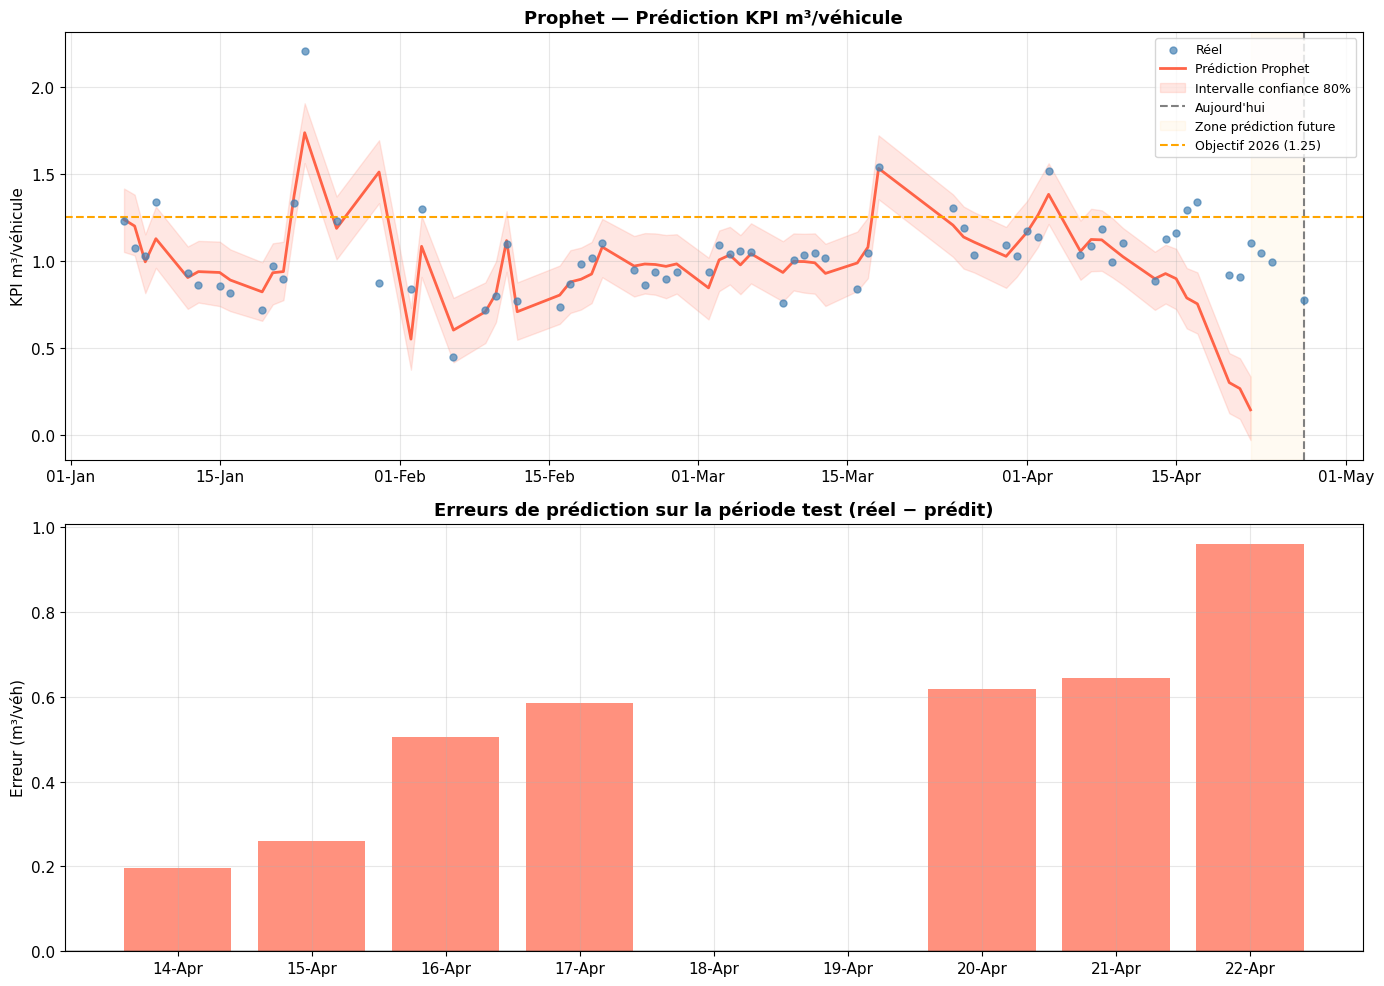

Graphique sauvegardé ✓


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Graphique 1 : Prédiction vs Réalité ──────────────────────
ax1 = axes[0]

# Données réelles
ax1.scatter(df_prophet['ds'], df_prophet['y'],
            color='steelblue', s=25, alpha=0.7, label='Réel', zorder=3)

# Prédiction
pred_dates = forecast['ds']
ax1.plot(pred_dates, forecast['yhat'],
         color='tomato', linewidth=2, label='Prédiction Prophet')

# Bande de confiance
ax1.fill_between(pred_dates,
                 forecast['yhat_lower'],
                 forecast['yhat_upper'],
                 alpha=0.15, color='tomato', label='Intervalle confiance 80%')

# Zone future (les 7 derniers jours)
derniere_date_reelle = df_prophet['ds'].max()
ax1.axvline(x=derniere_date_reelle, color='gray',
            linestyle='--', linewidth=1.5, label='Aujourd\'hui')
ax1.axvspan(derniere_date_reelle, pred_dates.max(),
            alpha=0.05, color='orange', label='Zone prédiction future')

# Objectif
ax1.axhline(y=1.25, color='orange', linestyle='--',
            linewidth=1.5, label='Objectif 2026 (1.25)')

ax1.set_title('Prophet — Prédiction KPI m³/véhicule', fontweight='bold', fontsize=13)
ax1.set_ylabel('KPI m³/véhicule')
ax1.legend(loc='upper right', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.grid(True, alpha=0.3)

# ── Graphique 2 : Erreurs sur le test ────────────────────────
ax2 = axes[1]

# Fusionner réel vs prédit sur la période test
test_dates = df_test['ds'].values
pred_test = forecast[forecast['ds'].isin(test_dates)][['ds','yhat']]
compare = df_test.merge(pred_test, on='ds')
compare['erreur'] = compare['y'] - compare['yhat']

ax2.bar(compare['ds'], compare['erreur'],
        color=compare['erreur'].apply(lambda x: 'tomato' if x > 0 else 'steelblue'),
        alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_title('Erreurs de prédiction sur la période test (réel − prédit)',
              fontweight='bold', fontsize=13)
ax2.set_ylabel('Erreur (m³/véh)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/prophet_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

In [10]:
# Calculer MAE et MAPE sur la période test
pred_test  = forecast[forecast['ds'].isin(df_test['ds'].values)][['ds','yhat']]
compare    = df_test.merge(pred_test, on='ds')

mae  = mean_absolute_error(compare['y'], compare['yhat'])
rmse = np.sqrt(mean_squared_error(compare['y'], compare['yhat']))
mape = np.mean(np.abs((compare['y'] - compare['yhat']) / compare['y'])) * 100

print("=== PERFORMANCE PROPHET ===")
print(f"MAE  (erreur moyenne absolue) : {mae:.4f} m³/véh")
print(f"RMSE (erreur quadratique)     : {rmse:.4f} m³/véh")
print(f"MAPE (erreur en %)            : {mape:.2f}%")
print()
if mape < 10:
    print("✅ Excellente précision (MAPE < 10%)")
elif mape < 20:
    print("✅ Bonne précision (MAPE < 20%)")
else:
    print("⚠️  Précision à améliorer — dataset encore petit (112 jours)")
    print("   → S'améliorera naturellement avec plus de données")

=== PERFORMANCE PROPHET ===
MAE  (erreur moyenne absolue) : 0.5383 m³/véh
RMSE (erreur quadratique)     : 0.5881 m³/véh
MAPE (erreur en %)            : 49.77%

⚠️  Précision à améliorer — dataset encore petit (112 jours)
   → S'améliorera naturellement avec plus de données


In [11]:
# XGBoost prédit le KPI à partir de toutes les features disponibles

FEATURES = [
    'TCM', 'ED_Total', 'EOR_Total', 'EI_Facturation', 'EP_Facturation',
    'jour_semaine', 'mois', 'trimestre', 'is_lundi',
    'ratio_EOR_ED', 'taux_EP', 'taux_EI'
]
TARGET = 'KPI_m3_veh'
# Vérification des colonnes manquantes
missing_cols = [c for c in FEATURES + [TARGET] if c not in df_prod.columns]
print(f"Colonnes manquantes : {missing_cols}")
# Préparer X et y
df_xgb = df_prod[FEATURES + [TARGET]].dropna().copy()
X = df_xgb[FEATURES]
y = df_xgb[TARGET]

# Split 80% train / 20% test (chronologique — pas aléatoire)
split = int(len(df_xgb) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train : {len(X_train)} jours")
print(f"Test  : {len(X_test)} jours")
print(f"Features utilisées : {len(FEATURES)}")

Colonnes manquantes : []
Train : 54 jours
Test  : 14 jours
Features utilisées : 12


In [12]:
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model_xgb.fit(X_train, y_train)

# Prédictions
y_pred = model_xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mape_xgb = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print("=== PERFORMANCE XGBOOST ===")
print(f"MAE  : {mae_xgb:.4f} m³/véh")
print(f"RMSE : {rmse_xgb:.4f} m³/véh")
print(f"MAPE : {mape_xgb:.2f}%")

=== PERFORMANCE XGBOOST ===
MAE  : 0.0646 m³/véh
RMSE : 0.0749 m³/véh
MAPE : 6.15%


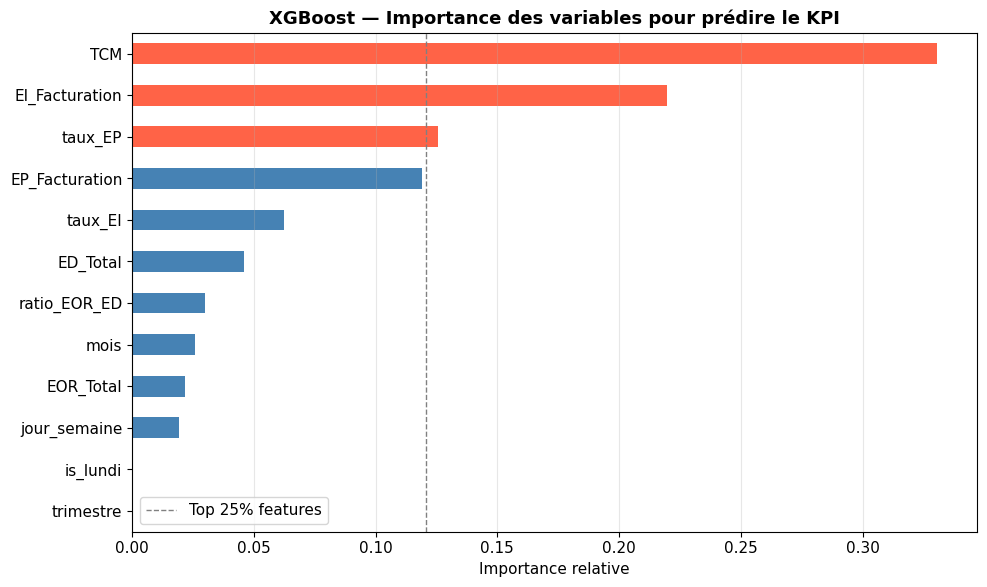

Graphique sauvegardé ✓


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = pd.Series(model_xgb.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

colors = ['tomato' if v > importances.quantile(0.75) else 'steelblue'
          for v in importances]

importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost — Importance des variables pour prédire le KPI',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance relative')
ax.axvline(x=importances.quantile(0.75), color='gray',
           linestyle='--', linewidth=1, label='Top 25% features')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/xgboost_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

In [14]:
print("=" * 45)
print("  COMPARAISON FINALE DES MODÈLES")
print("=" * 45)
print(f"{'Métrique':<15} {'Prophet':>12} {'XGBoost':>12}")
print("-" * 45)
print(f"{'MAE':<15} {mae:>12.4f} {mae_xgb:>12.4f}")
print(f"{'RMSE':<15} {rmse:>12.4f} {rmse_xgb:>12.4f}")
print(f"{'MAPE':<15} {mape:>11.2f}% {mape_xgb:>11.2f}%")
print("=" * 45)
print()
print("Utilisation recommandée :")
print("  Prophet  → prédiction 7 jours futurs (série temporelle)")
print("  XGBoost  → explication des causes    (importance features)")

  COMPARAISON FINALE DES MODÈLES
Métrique             Prophet      XGBoost
---------------------------------------------
MAE                   0.5383       0.0646
RMSE                  0.5881       0.0749
MAPE                  49.77%        6.15%

Utilisation recommandée :
  Prophet  → prédiction 7 jours futurs (série temporelle)
  XGBoost  → explication des causes    (importance features)


In [15]:
# Sauvegarder les modèles entraînés pour le pipeline automatique
joblib.dump(model_xgb,     "../models/model_xgboost.pkl")
joblib.dump(model_prophet, "../models/model_prophet.pkl")

print("Modèles sauvegardés ✓")
print("  ../models/model_xgboost.pkl")
print("  ../models/model_prophet.pkl")
print()
print("Ces fichiers seront chargés automatiquement par le pipeline")
print("quotidien — sans réentraînement à chaque fois.")

Modèles sauvegardés ✓
  ../models/model_xgboost.pkl
  ../models/model_prophet.pkl

Ces fichiers seront chargés automatiquement par le pipeline
quotidien — sans réentraînement à chaque fois.
